**Index No.:** 230280L  
**Name:** J. A. P. R. Jayasinghe  

# EN3160 Assignment 1
## Intensity Transformations and Neighborhood Filtering

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Question 1**

In [28]:
def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints, dtype=np.float64)

    im_float = im.astype(np.float64)
    out = np.zeros_like(im_float)

    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]

        if x1 == x0:
            continue  # vertical jump, no input range to map

        mask = (im_float >= x0) & (im_float < x1)
        slope = (y1 - y0) / (x1 - x0)
        out[mask] = y0 + slope * (im_float[mask] - x0)

    out[im_float == breakpoints[-1, 0]] = breakpoints[-1, 1]
    out = np.clip(out, 0, 255).astype(np.uint8)

    # Build a 256-point curve for plotting only
    all_x = np.arange(256, dtype=np.float64)
    curve = np.zeros_like(all_x)
    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]
        if x1 == x0:
            continue
        mask = (all_x >= x0) & (all_x < x1)
        slope = (y1 - y0) / (x1 - x0)
        curve[mask] = y0 + slope * (all_x[mask] - x0)
    curve[-1] = breakpoints[-1, 1]

    return out, curve

In [29]:
# ---- Load image (grayscale) ----
img = cv2.imread('Images/img1.jpeg', cv2.IMREAD_GRAYSCALE)

breakpoints = [
    [0, 0],
    [50, 50],
    [50, 100],
    [100, 175],
    [150, 255],
    [150, 150],
    [255, 255],
]

transformed, curve = intensity_transform(img, breakpoints)

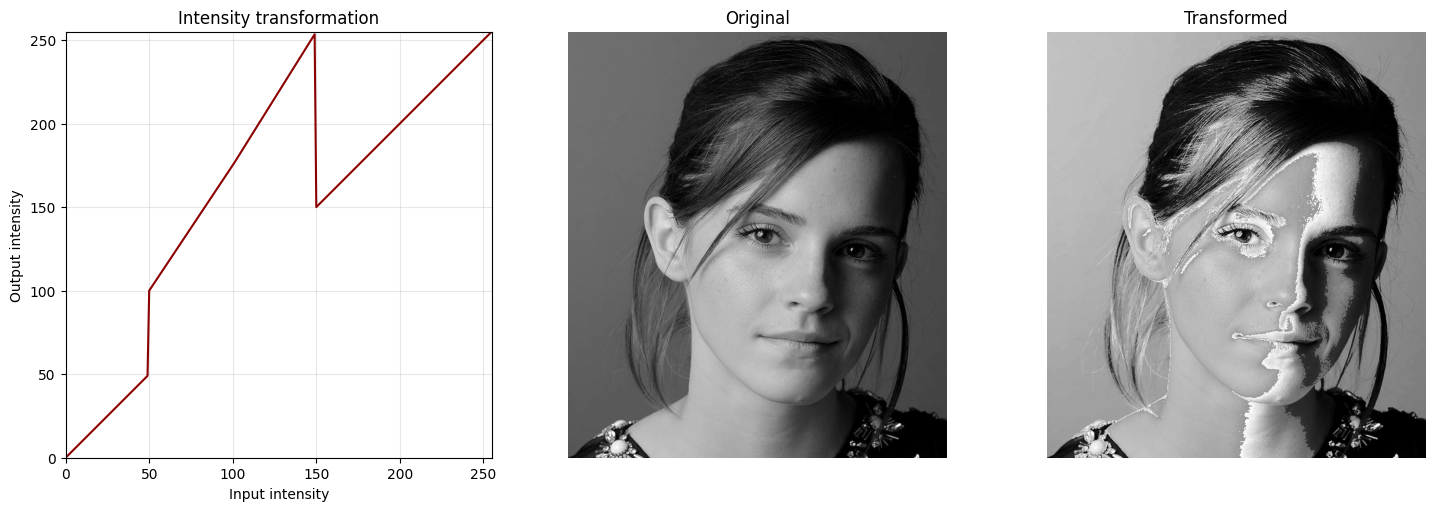

In [30]:
# ---- Plot everything in a single row: curve, original, transformed ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), curve, color='darkred')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity transformation')
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

axes[1].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(transformed, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Transformed')
axes[2].axis('off')

plt.tight_layout()
plt.show()